In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [91]:
session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"]

exp_nickname = ['JAL004_2024_09_03', 'JAL004_2024_09_19', 'JAL004_2024_08_28', 'JAL004_2024_09_11',
                'JAL005_2024_09_08', 'JAL005_2024_09_21',
                'JAL006_2024_03_28', 'JAL006_2024_03_21', 'JAL006_2024_03_18', 'JAL006_2024_03_25',
                'JAL007_2024_04_09', 'JAL007_2024_03_22', 'JAL007_2024_03_12', 'JAL007_2024_04_16', 'JAL007_2024_04_23',
                'JAL008_2024_04_25', 'JAL008_2024_04_29', 'JAL008_2024_05_07', 'JAL008_2024_05_14', 'JAL008_2024_05_10']

e = 17
session_name = session_names[e]

In [93]:
"""Load the dataset"""
save_path = "Z:\Jasmine_Laurence\summary_plots\Replay\SSdecoder"
cond_names = ['shelter_only', 'barrier', 'barrier_flip']
cond = 2
# load time, position, bin_width and spikes
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_data.npz')
time = data['time']
position = data['position']
bin_width = data['bin_width'] 
spikes = data['spikes'].T
tuning_curves = data['tuning_curve']
sampling_frequency = 1000

In [ ]:
import warnings
np.warnings = warnings
from replay_trajectory_classification import SortedSpikesDecoder, Environment, RandomWalk, estimate_movement_var

linear_track_env = Environment(
                            place_bin_size=1,  # Adjust based on your actual bin size
                            # track_graph=my_linear_graph,  # Define a linear graph with 25 nodes
                            edge_order=[(i, i + 1) for i in range(24)],  # Sequential edges
                            edge_spacing=None,  # No gaps between edges
                            position_range=[(0, 25)],  # 0 to 100% of escape route
                            infer_track_interior=False,  # Data is already binned
                            fill_holes=False,
                            dilate=False,
                            bin_count_threshold=1,
                        )
transition_type = RandomWalk(movement_var=1)

decoder = SortedSpikesDecoder(
                            environment=linear_track_env,
                            transition_type=transition_type,
                            sorted_spikes_algorithm='spiking_likelihood_kde',
                            sorted_spikes_algorithm_params={'block_size': None,
                                                            'position_std': [1.0],
                                                            'use_diffusion': False},
                        )

decoder.fit(position[:int(spikes.shape[0]/2)], spikes[:int(spikes.shape[0]/2),:])

SortedSpikesDecoder(environment=Environment(environment_name='',
                                            place_bin_size=1,
                                            track_graph=None,
                                            edge_order=[(0, 1), (1, 2), (2, 3),
                                                        (3, 4), (4, 5), (5, 6),
                                                        (6, 7), (7, 8), (8, 9),
                                                        (9, 10), (10, 11),
                                                        (11, 12), (12, 13),
                                                        (13, 14), (14, 15),
                                                        (15, 16), (16, 17),
                                                        (17, 18), (18, 19),
                                                        (19, 20), (20, 21),
                                                        (21, 22), (22, 23),
                                                        (23, 24)],
                                            edge_spacing=None,
                                            is_track_interior=None,
                                            position_range=[(0, 25)],
                                            i...
                                            dilate=False,
                                            bin_count_threshold=1),
                    infer_track_interior=True,
                    initial_conditions_type=UniformInitialConditions(),
                    sorted_spikes_algorithm='spiking_likelihood_kde',
                    sorted_spikes_algorithm_params={'block_size': None,
                                                    'position_std': [1.0],
                                                    'use_diffusion': False},
                    transition_type=RandomWalk(environment_name='',
                                               movement_var=1,
                                               movement_mean=0.0,
                                               use_diffusion=False))

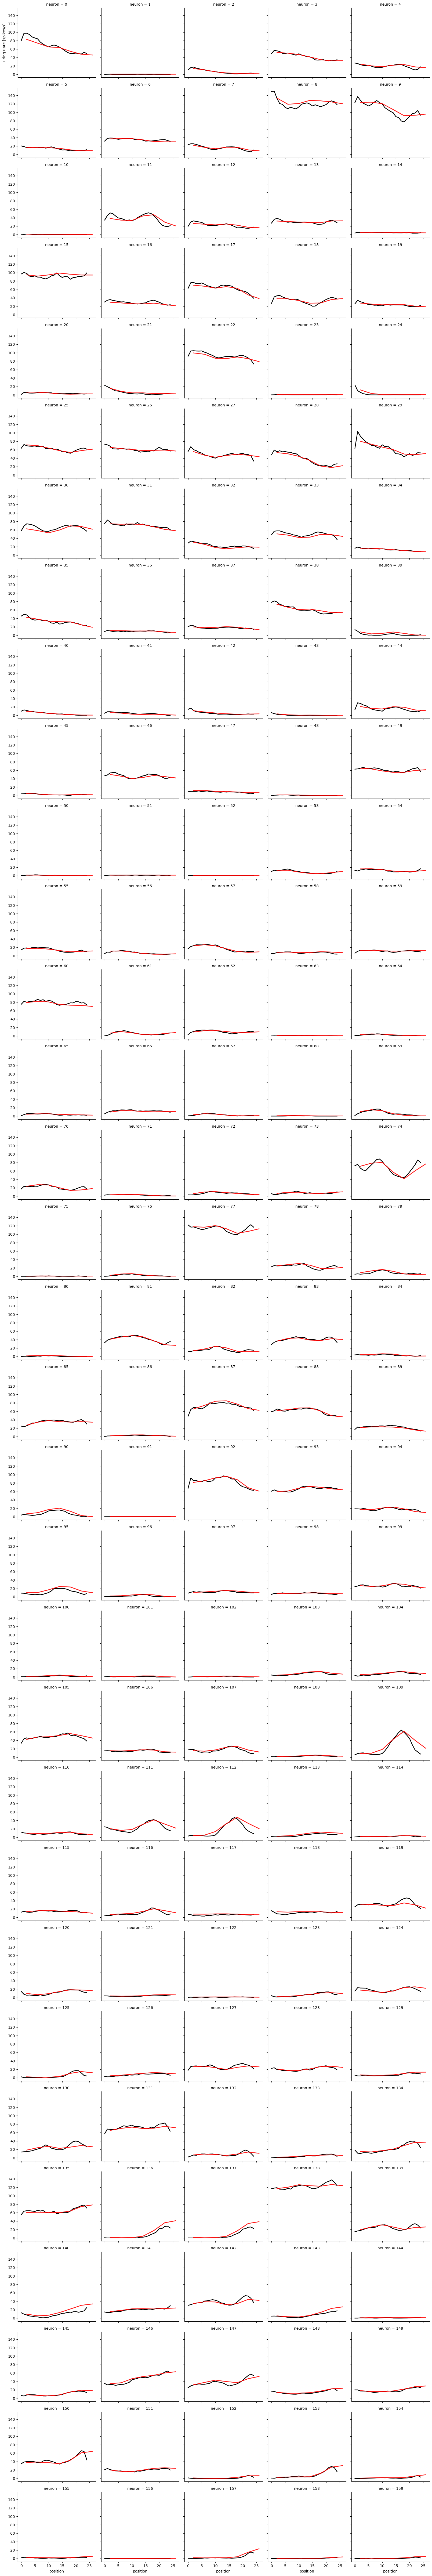

In [60]:
"""Look at the escape tuning"""
g = (decoder.place_fields_ * sampling_frequency).plot(
        x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
for ax, place_field in zip(g.axes.flat, tuning_curves):
    ax.plot(np.arange(25), place_field, linewidth=2, color="black", zorder=-1, label="True")
sns.despine()

100%|██████████| 107/107 [00:01<00:00, 71.81it/s]


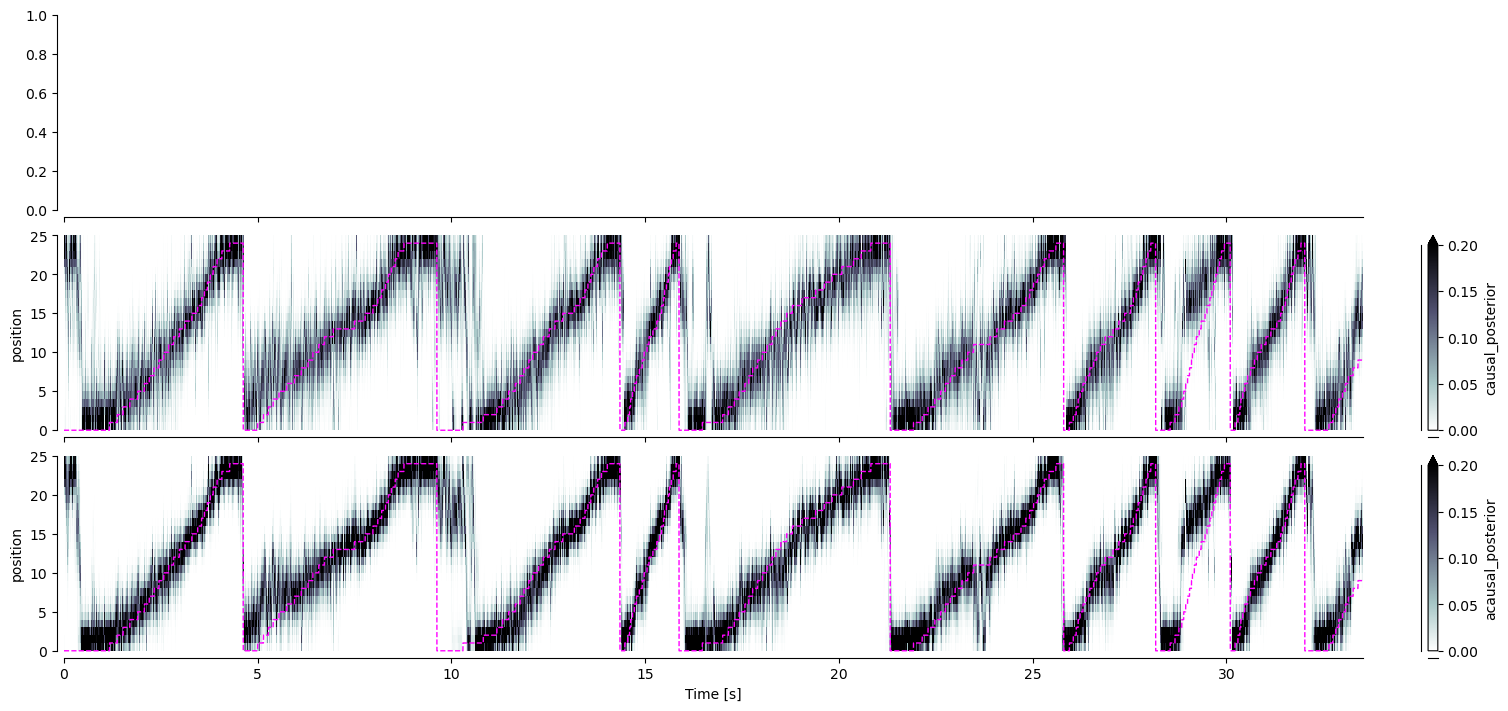

In [ ]:
results = decoder.predict(spikes[:int(spikes.shape[0]/2),:], time=time[:int(spikes.shape[0]/2)])

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

spike_time_ind, neuron_ind = np.nonzero(spikes[:int(spikes.shape[0]/2),:])
ax0 = axes[0]
t = time[:int(spikes.shape[0]/2)]
ax0.scatter(t[spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
ax0.set_yticks((0, spikes[:int(spikes.shape[0]/2),:].shape[1]))
ax0.set_ylabel('Neuron Index')

results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[1].plot(time[:int(spikes.shape[0]/2):], position[:int(spikes.shape[0]/2)], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[1].set_xlabel("")
results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[2].plot(time[:int(spikes.shape[0]/2)], position[:int(spikes.shape[0]/2)], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[2].set_xlabel('Time [s]')

sns.despine(offset=5)

  0%|          | 0/160 [00:00<?, ?it/s]

100%|██████████| 160/160 [00:04<00:00, 36.02it/s]


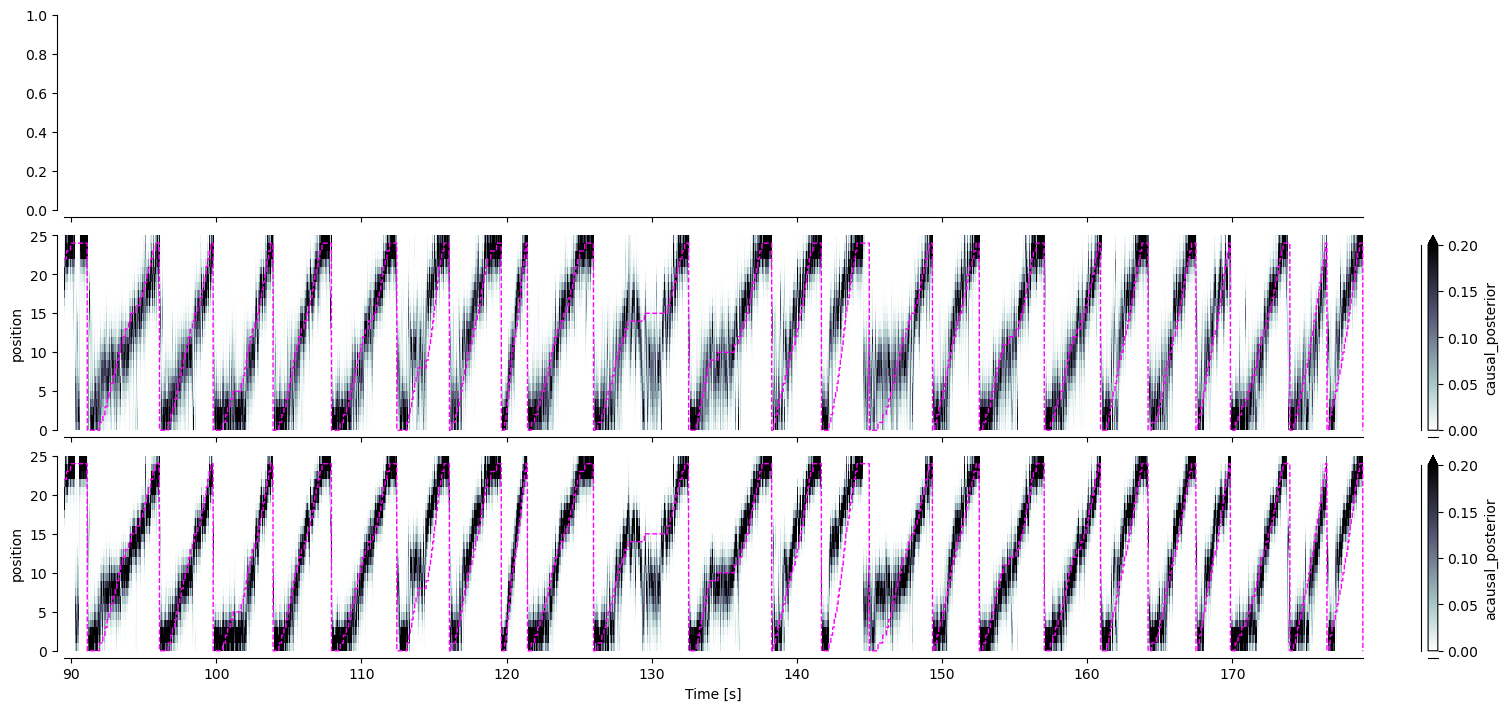

In [ ]:
"""Estimate the escape position from the model"""
results = decoder.predict(spikes[int(spikes.shape[0]/2):,:], time=time[int(spikes.shape[0]/2):])

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

# axes[0].imshow(spikes.T, cmap="gray_r", aspect="auto", interpolation="none",
#                     extent=(0, spikes.shape[0]/(1/bin_width), 0, spikes.shape[1]))
# axes[0].set_ylabel('Cells')

results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[1].plot(time[int(spikes.shape[0]/2):], position[int(spikes.shape[0]/2):], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[1].set_xlabel("")
results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[2].plot(time[int(spikes.shape[0]/2):], position[int(spikes.shape[0]/2):], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[2].set_xlabel('Time [s]')

sns.despine(offset=5)

100%|██████████| 107/107 [00:02<00:00, 38.36it/s]


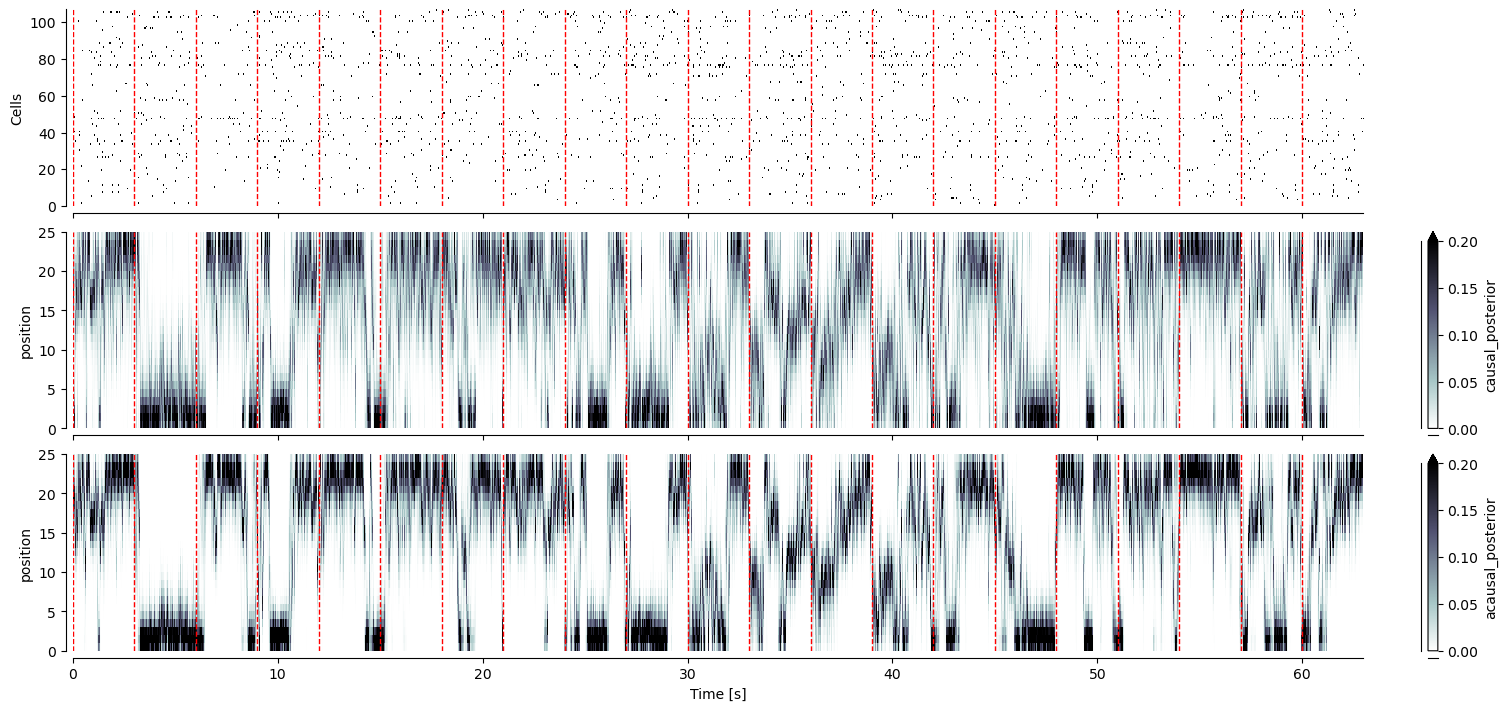

In [101]:
"""Test the decoder on the prehoming period"""
data = np.load(save_path + '\\' + session_name + '_' + cond_names[cond] + '_state_space_decoder_prehomie_data.npz')
pre_time = data['time']
bin_width = data['bin_width'] 
pre_spikes = data['spikes'].T

pre_results = decoder.predict(pre_spikes, time=pre_time)

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

axes[0].imshow(pre_spikes.T, cmap="gray_r", aspect="auto", interpolation="none",
                    extent=(0, pre_spikes.shape[0]/(1/bin_width), 0, pre_spikes.shape[1]))
axes[0].set_ylabel('Cells')

pre_results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[1].set_xlabel("")
pre_results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[2].set_xlabel('Time [s]')

for ax in axes:
    for i in np.arange(0,pre_time[-1],3):
        ax.axvline(i, color='red', linestyle='--', linewidth=1)
sns.despine(offset=5)